# Проект: классификация

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [31]:
df = pd.read_csv('bank_fin.csv', sep = ';')

In [32]:
# Проверим количество пропусков по каждому столбцу
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [33]:
# Проверим, есть ли явные NaN в job
print("Количество NaN:", df['job'].isnull().sum())

# Проверим, есть ли 'unknown' как скрытые пропуски
print("Количество 'unknown':", (df['job'] == 'unknown').sum())

# Посмотрим, какие вообще есть уникальные значения
df['job'].unique()

Количество NaN: 0
Количество 'unknown': 70


array(['admin.', 'technician', 'services', 'management', 'retired',
       'blue-collar', 'unemployed', 'entrepreneur', 'housemaid',
       'unknown', 'self-employed', 'student'], dtype=object)

### Задание 3

In [34]:
# 1) берём как строки
s = df['balance'].astype(str)

# 2) оставляем только цифры и возможные разделители , . -
s = s.str.replace(r'[^\d,.\-]', '', regex=True)

# 3) приводим запятую к точке
s = s.str.replace(',', '.', regex=False)

# 4) если точки нет, вставляем её перед последними двумя цифрами (копейки)
mask = ~s.str.contains(r'\.')
s.loc[mask] = s.loc[mask].str.replace(r'(\d{2})$', r'.\1', regex=True)

# 5) переводим в число
df['balance'] = pd.to_numeric(s, errors='coerce')

# проверка
print(df['balance'].dtype)
print(df['balance'].head())
print('mean (round 3):', round(df['balance'].mean(), 3))

float64
0    2343.0
1      45.0
2    1270.0
3    2476.0
4     184.0
Name: balance, dtype: float64
mean (round 3): 1529.129


### Задание 4

In [35]:
# Считаем медиану по balance
median_balance = df['balance'].median()

# Заполняем пропуски медианой
df['balance'] = df['balance'].fillna(median_balance)

# Проверим, остались ли пропуски
print("Пропусков осталось:", df['balance'].isnull().sum())
print("Медиана:", median_balance)

Пропусков осталось: 0
Медиана: 550.0


### Задание 5

In [36]:
# Заполняем пропуски (NaN) модальными значениями
df['job'] = df['job'].fillna(df['job'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])

# Дополнительно: заменим "unknown" на моду, если такие значения есть
df['job'] = df['job'].replace('unknown', df['job'].mode()[0])
df['education'] = df['education'].replace('unknown', df['education'].mode()[0])

# Проверим результат
print("Пропуски в job:", df['job'].isnull().sum())
print("Пропуски в education:", df['education'].isnull().sum())

Пропуски в job: 0
Пропуски в education: 0


### Задание 6

In [37]:
# Границы по методу Тьюки
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Фильтрация выбросов
before = len(df)
df = df[(df['balance'] >= lower) & (df['balance'] <= upper)].copy()
after = len(df)

print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
print(f"Нижняя граница: {lower:.3f}, верхняя: {upper:.3f}")
print(f"Удалено строк: {before - after}, осталось: {after}")

# Проверка, что выбросов не осталось
outliers_left = ((df['balance'] < lower) | (df['balance'] > upper)).sum()
print("Выбросов осталось:", outliers_left)

Q1=123.000, Q3=1699.000, IQR=1576.000
Нижняя граница: -2241.000, верхняя: 4063.000
Удалено строк: 1057, осталось: 10105
Выбросов осталось: 0


## Часть 2:  Разведывательный анализ

### Задание 1

Абсолютные частоты:
deposit
no     5424
yes    4681
Name: count, dtype: int64

Относительные частоты (%):
deposit
no     53.68
yes    46.32
Name: proportion, dtype: float64


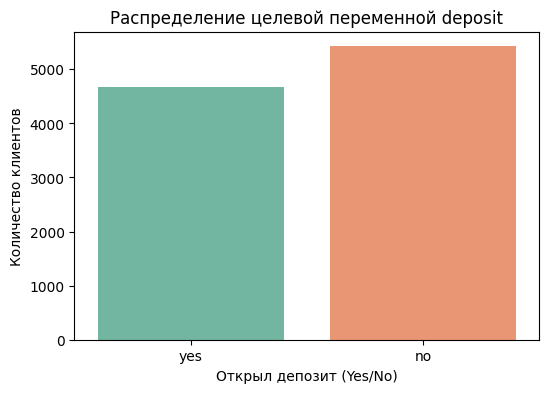

In [38]:
# Частоты по целевой переменной
class_counts = df['deposit'].value_counts()
class_percent = df['deposit'].value_counts(normalize=True) * 100

print("Абсолютные частоты:")
print(class_counts)
print("\nОтносительные частоты (%):")
print(class_percent.round(2))

# Визуализация
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df, palette='Set2')
plt.title('Распределение целевой переменной deposit')
plt.xlabel('Открыл депозит (Yes/No)')
plt.ylabel('Количество клиентов')
plt.show()

### Задания 2 и 3

In [40]:
# Описательные статистики для числовых переменных
desc_stats = df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']].describe().T

# Добавим медиану
desc_stats['median'] = df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']].median()

# Выведем результат
desc_stats

,count,mean,std,min,25%,50%,75%,max,median
age,10105.0,40.895497,11.734931,18.0,32.0,38.0,48.0,95.0,38.0
balance,10105.0,807.653538,994.151966,-2049.0,95.0,445.0,1227.0,4063.0,445.0
day,10105.0,15.590302,8.441510,1.0,8.0,15.0,22.0,31.0,15.0
duration,10105.0,368.742603,346.651524,2.0,137.0,252.0,490.0,3881.0,252.0
campaign,10105.0,2.517170,2.707159,1.0,1.0,2.0,3.0,43.0,2.0
pdays,10105.0,51.319644,109.644179,-1.0,-1.0,-1.0,2.0,854.0,-1.0
previous,10105.0,0.816230,2.243795,0.0,0.0,0.0,1.0,58.0,0.0


## Выводы по исследованию данных

### 1. Распределение целевой переменной `deposit`
- **53.68% клиентов отказались** от открытия депозита.  
- **46.32% согласились**.  
- Данные не идеально сбалансированы, но сильного перекоса нет (≈ 54% против 46%).  
- Это значит, что при обучении модели не потребуется серьёзных методов балансировки, но стоит учитывать небольшое преобладание класса *"no"*.

### 2. График распределения `deposit`
- На графике видно, что клиентов с ответом **"no"** немного больше, чем с ответом **"yes"**.  
- Баланс классов достаточно близок, что положительно скажется на обучении классификатора.

### 3. Описательные статистики количественных переменных

**Возраст (age):**
- Средний возраст клиентов ≈ 41 год.  
- Основная масса клиентов — 32–48 лет.  
- Минимум 18 лет, максимум 95 лет → есть редкие пожилые клиенты.  

**Баланс (balance):**
- Средний баланс ≈ 808, медиана 445 → распределение скошено вправо.  
- Есть отрицательные значения (–2049) → клиенты с долгами.  
- Максимум более 4000, стандартное отклонение высокое → разброс и выбросы.  

**День контакта (day):**
- Среднее ≈ 15.6, медиана 15 → звонки равномерно распределены по месяцам.  

**Длительность звонка (duration):**
- Среднее ≈ 369 сек (~6 мин), медиана 252 сек (~4 мин).  
- Есть длинные разговоры (до 3881 сек ≈ 1 час).  
- Вероятно, длительность звонка является важным фактором в открытии депозита.  

**Количество контактов в кампании (campaign):**
- Среднее ≈ 2.5, медиана 2.  
- Большинство клиентов контактировали 1–3 раза, но есть экстремальные значения (до 43 звонков).  

**pdays (дни после предыдущей кампании):**
- Медиана = –1 → большинство клиентов ранее не контактировались.  
- Значения варьируются до 854 → часть клиентов имела давние контакты.  

**previous (количество контактов до текущей кампании):**
- Среднее ≈ 0.8, медиана = 0 → большинство впервые контактировали в этой кампании.  
- Есть редкие клиенты с числом контактов до 58.  

---

### Итог:
- Основная аудитория банка — клиенты 30–50 лет.  
- Балансы сильно варьируются: есть клиенты с долгами и с большими положительными остатками.  
- Длительность звонка и история контактов могут оказаться решающими факторами в прогнозе открытия депозита.  

### Задания 4 и 5


job:
job
management       2315
blue-collar      1807
technician       1638
admin.           1246
services          868
retired           663
self-employed     358
unemployed        332
student           326
entrepreneur      300
housemaid         252
Name: count, dtype: int64
----------------------------------------

marital:
marital
married     5715
single      3213
divorced    1177
Name: count, dtype: int64
----------------------------------------

education:
education
secondary    5517
tertiary     3239
primary      1349
Name: count, dtype: int64
----------------------------------------

housing:
housing
no     5243
yes    4862
Name: count, dtype: int64
----------------------------------------

loan:
loan
no     8712
yes    1393
Name: count, dtype: int64
----------------------------------------

contact:
contact
cellular     7283
unknown      2161
telephone     661
Name: count, dtype: int64
----------------------------------------

month:
month
may    2617
jul    1418
aug    1385
j

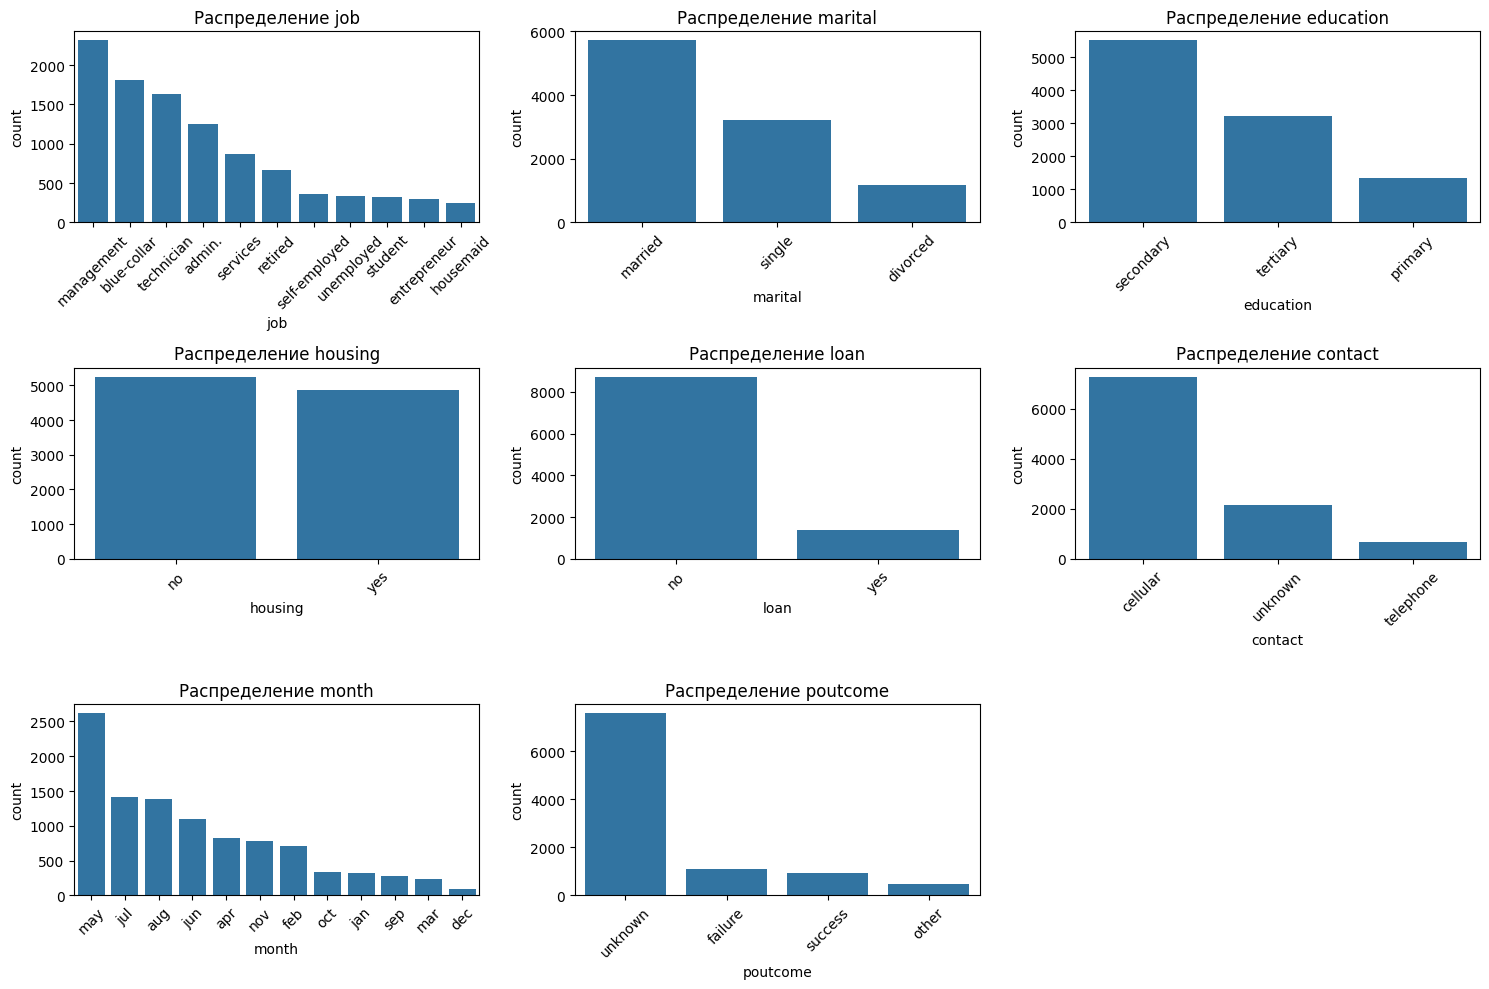

In [41]:
# Описательные статистики для категориальных признаков
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)

# Визуализация распределения категориальных переменных
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Распределение {col}")
plt.tight_layout()
plt.show()

## Выводы по категориальным признакам

### Работа (`job`)
- Наибольшее количество клиентов работает в сфере **management** и **blue-collar**.  
- Также много клиентов среди **technician** и **admin**.  
- Наименьшее количество среди **housemaid**, **entrepreneur** и безработных.  
- Это говорит о том, что банк в основном работает с людьми из офисного и производственного сектора.  

### Семейное положение (`marital`)
- Большинство клиентов — **married**.  
- Значительная часть — **single**, но их меньше в 1.5–2 раза.  
- Клиенты в разводе встречаются редко.  

### Образование (`education`)
- Преобладают клиенты со **secondary** образованием.  
- На втором месте — **tertiary (высшее образование)**.  
- Доля клиентов с **primary** образованием значительно ниже.  

### Наличие жилищного кредита (`housing`)
- Клиенты делятся почти поровну: около половины имеют ипотеку, половина — нет.  
- Это может быть важным фактором при прогнозе, так как наличие обязательств может снижать склонность к депозитам.  

### Наличие потребительского кредита (`loan`)
- Большинство клиентов не имеют потребительского кредита.  
- Клиентов с кредитами в разы меньше, что отражает более финансово устойчивую аудиторию.  

### Способ связи (`contact`)
- Основной канал связи — **сотовая связь (cellular)**.  
- Фиксированные телефоны используются очень редко.  
- Значительная часть контактов указана как **unknown**, что может снижать качество анализа.  

### Месяц звонка (`month`)
- Пик активности наблюдается в **мае**, **июле** и **августе**.  
- В зимние месяцы (ноябрь–декабрь, январь–февраль) активность минимальна.  
- Это может указывать на сезонность маркетинговых кампаний.  

### Исход предыдущей кампании (`poutcome`)
- Большинство клиентов имеют значение **unknown**, то есть информации о прошлых кампаниях нет.  
- Среди тех, по кому данные есть, чаще встречается **failure**.  
- Успешные исходы (**success**) встречаются реже, но именно они могут быть индикатором склонности клиента к депозиту.  

---

## Итог
- Банк работает преимущественно с клиентами из среднего класса (работающие в управлении, на производстве и в техсфере).  
- Большинство клиентов имеют среднее или высшее образование и состоят в браке.  
- Наличие кредитов варьируется, но ипотека встречается часто, в отличие от потребительских займов.  
- Основной канал коммуникации — мобильная связь.  
- Наибольшая активность звонков приходится на весну и лето, что может быть связано с сезонностью банковских предложений.  

### Задание 6

Доли успеха и неудачи по каждому статусу предыдущей кампании (%):
deposit      no    yes
poutcome              
failure   50.68  49.32
other     44.91  55.09
success    8.89  91.11
unknown   60.26  39.74


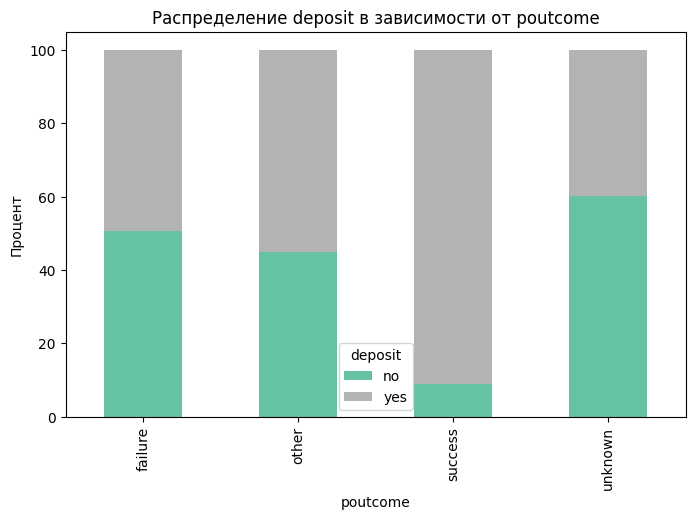

In [42]:
# Сводная таблица по poutcome и текущему результату deposit
poutcome_deposit = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100

print("Доли успеха и неудачи по каждому статусу предыдущей кампании (%):")
print(poutcome_deposit.round(2))

# Визуализация
poutcome_deposit.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set2')
plt.title('Распределение deposit в зависимости от poutcome')
plt.ylabel('Процент')
plt.xlabel('poutcome')
plt.legend(title='deposit')
plt.show()

### Вывод по результатам анализа `poutcome`

- Для клиентов, у которых **предыдущая кампания завершилась успехом (`success`)**, в текущей кампании вероятность открытия депозита крайне высока:  
  - **91.1%** клиентов открыли депозит, только **8.9%** отказались.  
  → Это яркий индикатор, что предыдущий успех сильно повышает шансы положительного исхода.

- Для категории **`other`** также наблюдается небольшой перевес в пользу успеха:  
  - **55.1%** клиентов открыли депозит против **44.9%** отказов.

- В случаях **`failure`** и особенно **`unknown`**, ситуация противоположная:  
  - При `failure` депозиты открыли лишь **49.3%** клиентов (чуть меньше половины).  
  - При `unknown` — ещё хуже: только **39.7%** согласились, а **60.3%** отказались.

📌 **Итого:**  
Наиболее перспективная группа — клиенты со статусом `success` в предыдущей кампании. Именно они демонстрируют наивысшую вероятность открытия депозита в текущей.  
Категории `failure` и `unknown` указывают на высокие риски отказа.

### Задание 7

Количество отказов по месяцам:
month
may    1776
jul     836
aug     775
jun     606
nov     456
feb     323
apr     317
jan     194
oct      62
sep      46
mar      24
dec       9
Name: count, dtype: int64


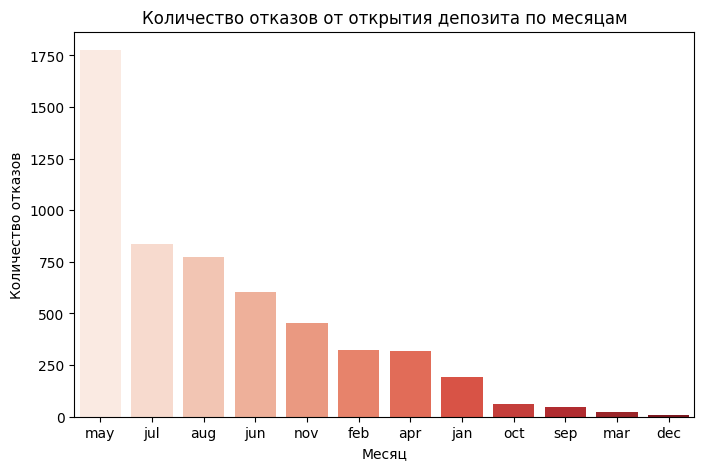

Больше всего отказов в месяце: may


In [43]:
# Считаем количество отказов по месяцам
refusals_by_month = df[df['deposit'] == 'no']['month'].value_counts()

print("Количество отказов по месяцам:")
print(refusals_by_month)

# Визуализация
plt.figure(figsize=(8,5))
sns.barplot(x=refusals_by_month.index, y=refusals_by_month.values, palette="Reds")
plt.title("Количество отказов от открытия депозита по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество отказов")
plt.show()

# Определим месяц с максимальным числом отказов
worst_month = refusals_by_month.idxmax()
print(f"Больше всего отказов в месяце: {worst_month}")

### Задание 7. Отказы от открытия депозита по месяцам

- Больше всего отказов от открытия депозита наблюдается в **мае** (более 1700 случаев).  
- Вторыми по количеству отказов идут **июль и август** — летние месяцы, когда клиенты менее активно принимают финансовые решения.  
- Минимальное количество отказов наблюдается в **декабре и марте**.  

📊 Таким образом, **май — наиболее проблемный месяц для маркетинговых кампаний**, и стоит уделить внимание дополнительной мотивации клиентов в этот период.

### Задание 8

deposit           no        yes
age_group                      
18-29      40.824742  59.175258
30-39      56.677607  43.322393
40-49      60.621327  39.378673
50-59      59.492140  40.507860
60+        24.042879  75.957121


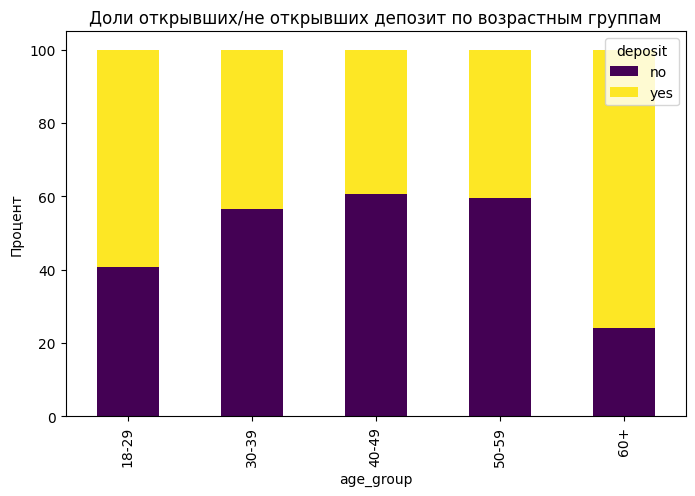

In [44]:
# Создадим возрастные группы
bins = [18, 30, 40, 50, 60, 100]  
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Посчитаем доли открывших депозит по возрастным группам
age_deposit = df.groupby('age_group')['deposit'].value_counts(normalize=True).unstack() * 100

print(age_deposit)

# Визуализация
age_deposit.plot(kind='bar', stacked=True, figsize=(8,5), colormap="viridis")
plt.title("Доли открывших/не открывших депозит по возрастным группам")
plt.ylabel("Процент")
plt.show()

### Анализ возрастных групп и склонности к открытию депозитов

- **18–29 лет**  
  Наибольшая доля открывших депозит (≈59%). Молодые клиенты чаще соглашаются на предложение банка.  

- **30–39 лет**  
  Доля открывших депозит снижается до ≈43%, большинство отказывается.  

- **40–49 лет**  
  Ещё меньше согласившихся — около 39%. В этой группе отказы преобладают.  

- **50–59 лет**  
  Ситуация схожа с предыдущей группой: около 41% открывают депозит, большинство отказывается.  

- **60+ лет**  
  Самая высокая доля открывших депозит (≈76%). Клиенты старшего возраста значительно чаще принимают предложение банка.  

### Вывод
- Наиболее склонны открывать депозит **молодые (18–29 лет)** и **пожилые клиенты (60+)**.  
- Наименее склонны открывать депозит клиенты среднего возраста (30–59 лет).  
- Вероятно, молодёжь более открыта к финансовым экспериментам, а пожилые клиенты ищут надёжные инструменты для сохранения накоплений.

### Задания 9 и 10

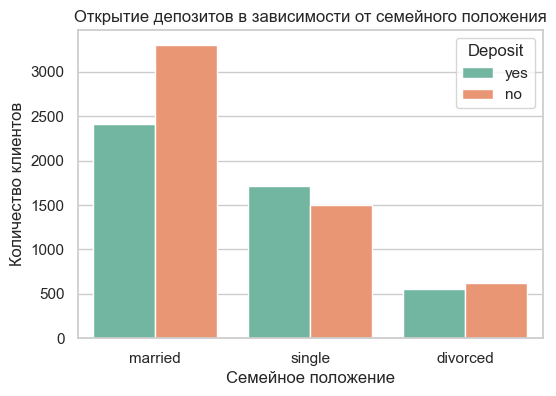

In [48]:
# Установим стиль
sns.set(style="whitegrid", palette="Set2")

# ---------- 1. Семейное положение ----------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="marital", hue="deposit")
plt.title("Открытие депозитов в зависимости от семейного положения")
plt.xlabel("Семейное положение")
plt.ylabel("Количество клиентов")
plt.legend(title="Deposit")
plt.show()

### 📊 Выводы по графику «Открытие депозитов в зависимости от семейного положения»

1. **Married (женатые/замужние)**  
   - Самая крупная группа клиентов.  
   - Большинство отказались от открытия депозита.  
   - Несмотря на это, значительная часть всё же открыла депозит.  

2. **Single (одинокие)**  
   - Доля открывших депозит выше, чем отказавшихся.  
   - Одинокие клиенты более склонны к финансовым вложениям.  

3. **Divorced (разведённые)**  
   - Наименьшая по численности группа.  
   - Количество открывших и отказавшихся примерно одинаково, с небольшим перевесом отказов.  

---

✅ **Общий вывод**:  
- Наиболее перспективная группа для маркетинговых кампаний — **одинокие клиенты**, так как вероятность открытия депозита у них выше.  
- Среди **женатых/замужних** преобладает отказ, но за счёт численности эта категория остаётся ключевой.  
- **Разведённые** клиенты демонстрируют слабый интерес к депозитам.  

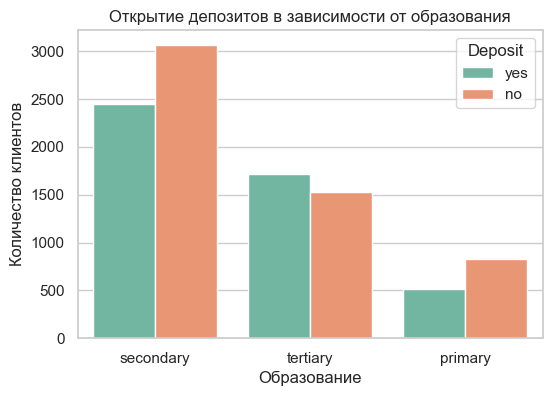

In [47]:
# ---------- 2. Образование ----------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="education", hue="deposit")
plt.title("Открытие депозитов в зависимости от образования")
plt.xlabel("Образование")
plt.ylabel("Количество клиентов")
plt.legend(title="Deposit")
plt.show()

### 📊 Выводы по графику «Открытие депозитов в зависимости от уровня образования»

1. **Secondary (среднее образование)**  
   - Самая крупная группа клиентов.  
   - Большинство отказались от открытия депозита.  
   - Однако значительная часть также открыла депозит → это ключевая категория для маркетинга.  

2. **Tertiary (высшее образование)**  
   - Баланс между открывшими и отказавшимися более равномерный.  
   - Чуть больше клиентов согласились открыть депозит, чем отказались.  
   - Люди с высшим образованием проявляют большую финансовую активность.  

3. **Primary (начальное образование)**  
   - Наименьшая группа.  
   - Большинство отказалось от открытия депозита.  
   - Открытие депозитов встречается реже.  

---

✅ **Общий вывод**:  
- Самая перспективная группа для открытия депозитов — **клиенты с высшим образованием (tertiary)**.  
- Клиенты со **средним образованием** представляют наибольший интерес из-за своей численности, но склонность к отказу выше.  
- Клиенты с **начальным образованием** чаще всего отказываются от депозитов.  

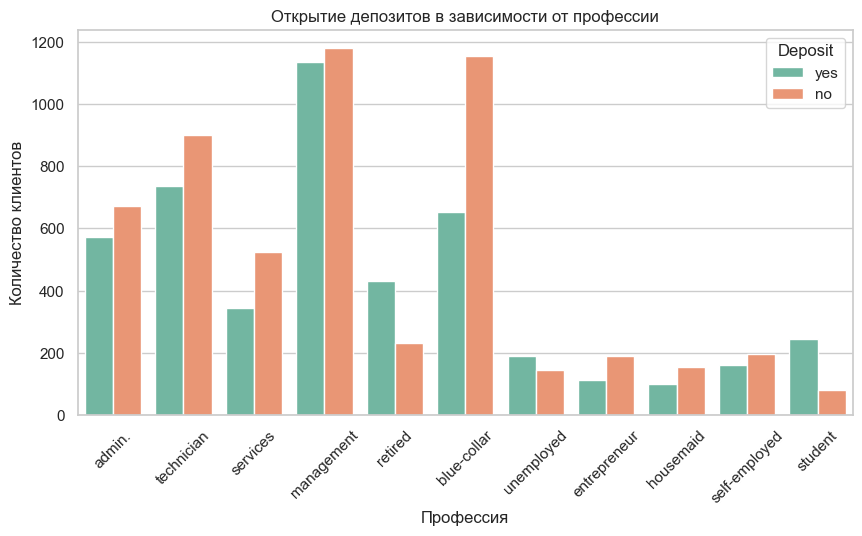

In [46]:
# ---------- 3. Профессия ----------
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="job", hue="deposit")
plt.title("Открытие депозитов в зависимости от профессии")
plt.xlabel("Профессия")
plt.ylabel("Количество клиентов")
plt.xticks(rotation=45)
plt.legend(title="Deposit")
plt.show()

### 📊 Выводы по графику «Открытие депозитов в зависимости от профессии»

1. **Management (менеджмент)**  
   - Самая крупная группа по численности.  
   - Количество открывших и не открывших депозит почти одинаково.  
   - Это ключевая целевая аудитория для маркетинговых кампаний.  

2. **Technician (технические специалисты)**  
   - Преобладает отказ от открытия депозита.  
   - Однако доля открывших тоже значительна → перспективная группа.  

3. **Blue-collar (рабочие)**  
   - Наибольшая склонность к отказу от депозита.  
   - Требует особого подхода в маркетинге, так как отказов существенно больше.  

4. **Retired (пенсионеры)**  
   - Открыли депозит значительно чаще, чем отказались.  
   - Очень перспективная аудитория для депозитных продуктов.  

5. **Students (студенты)**  
   - Большинство студентов открывают депозиты.  
   - Несмотря на небольшую численность группы, это очень положительная тенденция.  

6. **Admin., Services**  
   - Склонность к отказу выше, чем к открытию.  

7. **Self-employed (самозанятые)**  
   - Численность небольшая, распределение почти равное.  

8. **Unemployed, Housemaid, Entrepreneur**  
   - Самые малочисленные группы.  
   - В основном склонны отказываться от открытия депозитов.  

---

✅ **Общий вывод**:  
- Наиболее перспективные категории клиентов: **пенсионеры (retired)**, **студенты (students)** и **менеджеры (management)**.  
- Группы с наибольшим количеством отказов: **blue-collar**, **services** и **technician**.  
- Для разных профессий необходимы **дифференцированные маркетинговые стратегии**.  

### Задание 11

marital    divorced  married  single  Total
education                                  
secondary       283     1289     879   2451
tertiary        174      784     755   1713
primary          96      339      82    517


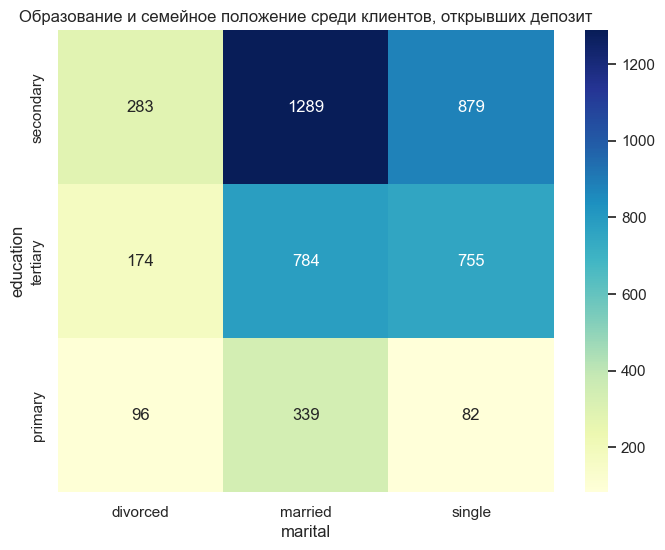

In [49]:
# Сводная таблица: образование + семейное положение среди открывших депозит
pivot = df[df['deposit'] == 'yes'].pivot_table(
    index='education',
    columns='marital',
    values='deposit',
    aggfunc='count',
    fill_value=0
)

# Добавим колонку "Итого"
pivot['Total'] = pivot.sum(axis=1)

# Отсортируем по убыванию
pivot = pivot.sort_values(by='Total', ascending=False)

print(pivot)

plt.figure(figsize=(8,6))
sns.heatmap(pivot.iloc[:,:-1], annot=True, fmt="d", cmap="YlGnBu")
plt.title("Образование и семейное положение среди клиентов, открывших депозит")
plt.show()

## 📊 Выводы по графику «Образование × Семейное положение» среди клиентов, открывших депозит  

1. **Клиенты со средним образованием (secondary)** и статусом **married (женатые/замужние)**  
   - Наибольшая группа среди всех категорий — **1289 человек**.  
   - Это ключевой сегмент по открытию депозитов.  

2. **Клиенты со средним образованием и статусом single (одинокие)**  
   - Вторая по численности группа — **879 человек**.  
   - Одинокие со средним образованием проявляют высокий интерес к депозитам.  

3. **Клиенты с высшим образованием (tertiary)**:  
   - married — **784**,  
   - single — **755**,  
   - divorced — **174**.  
   🔹 Эти группы уступают по численности клиентам со средним образованием, но также демонстрируют значительный интерес.  

4. **Клиенты с начальным образованием (primary)**:  
   - married — **339**,  
   - divorced — **96**,  
   - single — **82**.  
   🔹 Наименее активны в открытии депозитов, численность этих категорий заметно ниже.  

---

👉 **Главный вывод**:  
- Наиболее перспективные сегменты для маркетинговых кампаний:  
  1. **Женатые/замужние клиенты со средним образованием** (самая многочисленная группа).  
  2. **Одинокие со средним и высшим образованием**, которые также активно открывают депозиты.  
- Минимальное внимание можно уделить клиентам с **начальным образованием**, так как они менее склонны к депозитам.  

## Часть 3: преобразование данных

### Задание 1

In [50]:
# создаём объект LabelEncoder
le = LabelEncoder()

# преобразуем признак education
df['education_encoded'] = le.fit_transform(df['education'])

# посмотрим, как закодировались категории
print("Кодировка категорий образования:", dict(zip(le.classes_, le.transform(le.classes_))))
df[['education', 'education_encoded']].head()

Кодировка категорий образования: {'primary': np.int64(0), 'secondary': np.int64(1), 'tertiary': np.int64(2)}


,education,education_encoded
0,secondary,1
1,secondary,1
2,secondary,1
3,secondary,1
4,tertiary,2


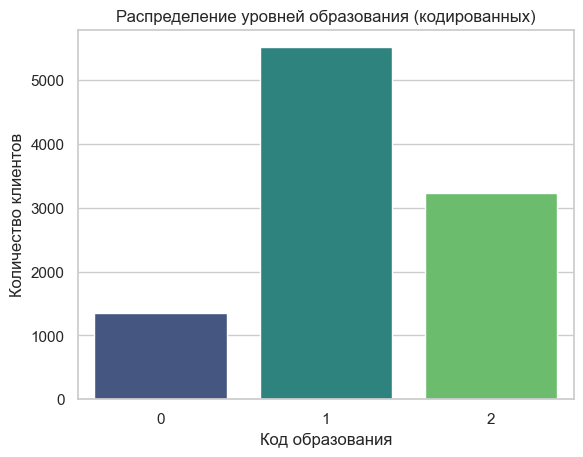

In [51]:
sns.countplot(x='education_encoded', data=df, palette='viridis')
plt.title("Распределение уровней образования (кодированных)")
plt.xlabel("Код образования")
plt.ylabel("Количество клиентов")
plt.show()

### Задания 2 и 3

In [52]:
# Преобразуем бинарные переменные в формат 0/1
binary_vars = ['default', 'housing', 'loan']

for col in binary_vars:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Проверим результат
df[binary_vars].head()

,default,housing,loan
0,0,1,0
1,0,0,0
2,0,1,0
3,0,1,0
4,0,0,0


In [56]:
# Перекодировка целевой переменной deposit
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Проверим результат
print(df['deposit'].value_counts())

deposit
0    5424
1    4681
Name: count, dtype: int64


In [59]:
le = LabelEncoder()
df['age_group_encoded'] = le.fit_transform(df['age_group'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df[['age_group', 'age_group_encoded']].head())

{'18-29': np.int64(0), '30-39': np.int64(1), '40-49': np.int64(2), '50-59': np.int64(3), '60+': np.int64(4)}
  age_group  age_group_encoded
0     50-59                  3
1     50-59                  3
2     40-49                  2
3     50-59                  3
4     50-59                  3


### Задание 4

In [53]:
# Список номинальных переменных
nominal_vars = ['job', 'marital', 'contact', 'month', 'poutcome']

# Создание dummy-переменных
df = pd.get_dummies(df, columns=nominal_vars, drop_first=True)

# Проверим результат
df.head()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,secondary,0,2343.0,1,0,5,1042,1,-1,...,False,False,False,True,False,False,False,False,False,True
1,56,secondary,0,45.0,0,0,5,1467,1,-1,...,False,False,False,True,False,False,False,False,False,True
2,41,secondary,0,1270.0,1,0,5,1389,1,-1,...,False,False,False,True,False,False,False,False,False,True
3,55,secondary,0,2476.0,1,0,5,579,1,-1,...,False,False,False,True,False,False,False,False,False,True
4,54,tertiary,0,184.0,0,0,5,673,2,-1,...,False,False,False,True,False,False,False,False,False,True


In [68]:
# Убираем все нечисловые признаки
df = df.select_dtypes(include=['int64', 'float64'])

print("Оставшиеся числовые признаки:")
print(df.columns)

Оставшиеся числовые признаки:
Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'pdays', 'previous', 'deposit', 'education_encoded',
       'age_group_encoded'],
      dtype='object')


### Задания 5 и 6

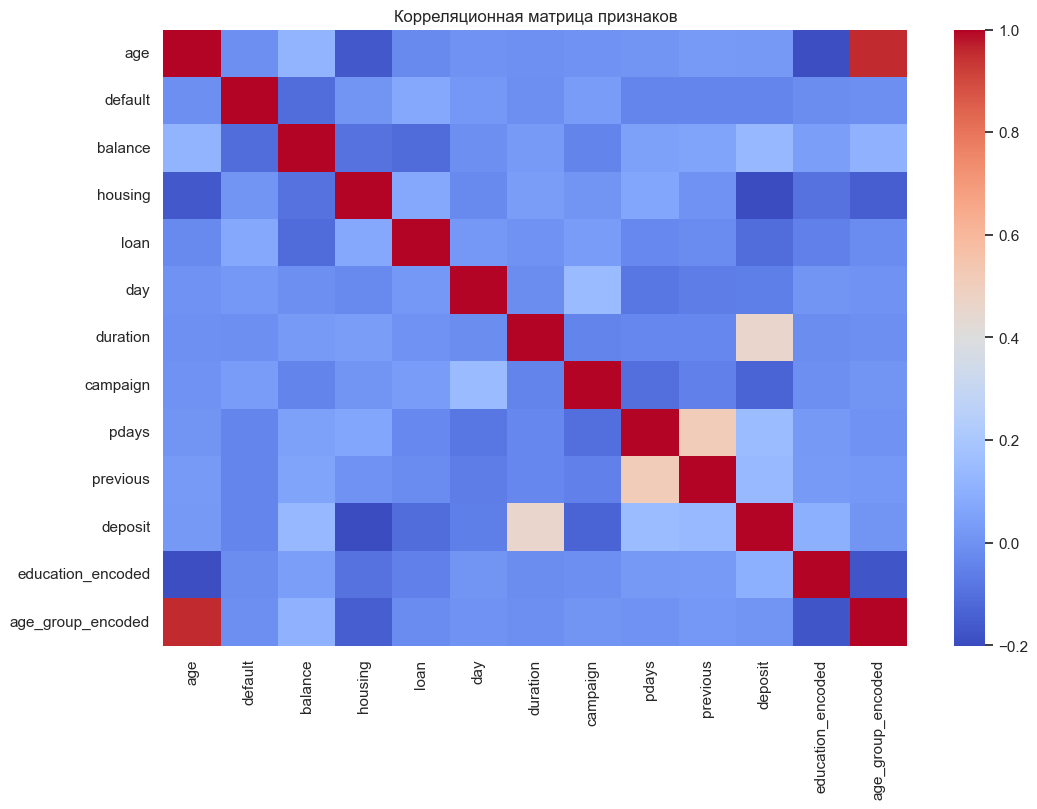

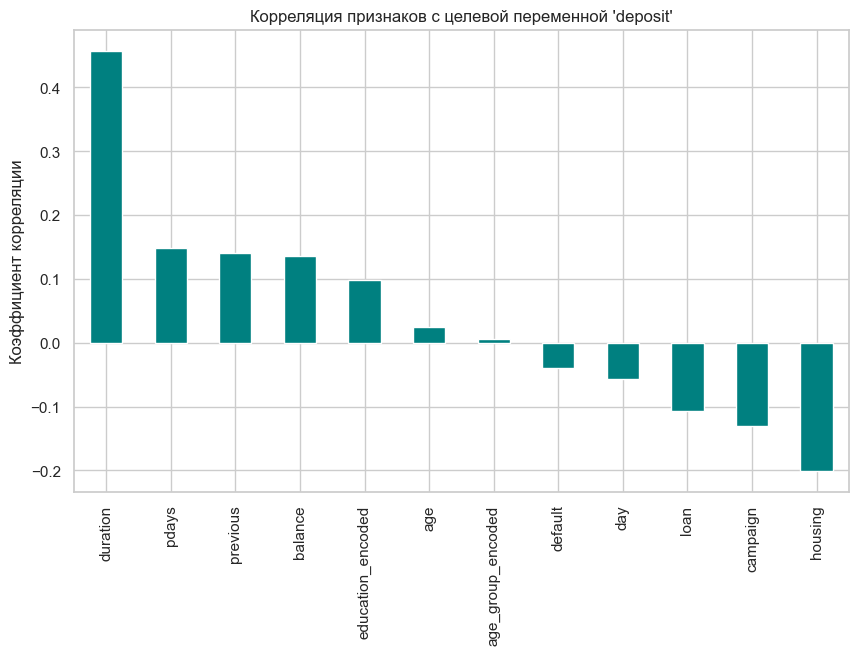

Признаки с высокой корреляцией между собой:
                       age  age_group_encoded
age                    NaN            0.95507
age_group_encoded  0.95507                NaN


In [69]:
# Построение корреляционной матрицы
corr_matrix = df.corr()

# Тепловая карта корреляций
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

# Корреляция с целевой переменной 'deposit'
corr_target = corr_matrix['deposit'].drop('deposit').sort_values(ascending=False)

# Столбчатая диаграмма корреляций с целевой переменной
plt.figure(figsize=(10,6))
corr_target.plot(kind='bar', color="teal")
plt.title("Корреляция признаков с целевой переменной 'deposit'")
plt.ylabel("Коэффициент корреляции")
plt.show()

# Вывод признаков с высокой корреляцией (для поиска мультиколлинеарности)
high_corr = corr_matrix[(corr_matrix > 0.7) & (corr_matrix < 1)]
print("Признаки с высокой корреляцией между собой:")
print(high_corr.dropna(axis=0, how='all').dropna(axis=1, how='all'))

In [70]:
# Удаляем age_group_encoded
df = df.drop(columns=['age_group_encoded'])

# Проверим, что удалили
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   default            10105 non-null  int64  
 2   balance            10105 non-null  float64
 3   housing            10105 non-null  int64  
 4   loan               10105 non-null  int64  
 5   day                10105 non-null  int64  
 6   duration           10105 non-null  int64  
 7   campaign           10105 non-null  int64  
 8   pdays              10105 non-null  int64  
 9   previous           10105 non-null  int64  
 10  deposit            10105 non-null  int64  
 11  education_encoded  10105 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 1.0 MB


### Задания 7 и 8

In [71]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [72]:
# Размер тестовой выборки
print("Размер тестовой выборки:", X_test.shape[0])

# Среднее значение целевой переменной в тестовой выборке
mean_target = round(y_test.mean(), 2)
print("Среднее значение целевой переменной (округлено):", mean_target)

Размер тестовой выборки: 3335
Среднее значение целевой переменной (округлено): 0.46


### Задание 9

In [73]:
# Выбор 15 лучших признаков
selector = SelectKBest(score_func=f_classif, k=15)
X_new = selector.fit_transform(X_train, y_train)

# Список отобранных признаков
selected_features = X_train.columns[selector.get_support()]
print("Отобранные признаки:", selected_features.tolist())

Отобранные признаки: ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'education_encoded']


### Задание 10

In [74]:
from sklearn.preprocessing import MinMaxScaler

# Создаем объект скейлера
scaler = MinMaxScaler()

# Применяем нормализацию
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабированные данные (пример):")
print(X_train_scaled[:5])

Масштабированные данные (пример):
[[0.21333333 0.         0.42637435 1.         0.         0.5
  0.13173498 0.         0.         0.         1.        ]
 [0.21333333 0.         0.34653141 0.         1.         0.8
  0.07579273 0.         0.24093567 0.03448276 1.        ]
 [0.2        0.         0.33524215 1.         0.         0.13333333
  0.10234597 0.02380952 0.41988304 0.0862069  1.        ]
 [0.25333333 0.         0.40788613 0.         0.         0.43333333
  0.03480278 0.         0.12046784 0.0862069  0.5       ]
 [0.28       0.         0.57149869 0.         0.         0.6
  0.02526424 0.         0.1380117  0.13793103 0.5       ]]


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [76]:
# Обучение модели
log_reg = LogisticRegression(solver='sag', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Предсказание
y_pred = log_reg.predict(X_test_scaled)

# Оценка качества
acc = accuracy_score(y_test, y_pred)
print(f"Точность модели: {acc:.4f}")

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))

Точность модели: 0.7730

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.77      0.82      0.80      1790
           1       0.78      0.71      0.74      1545

    accuracy                           0.77      3335
   macro avg       0.77      0.77      0.77      3335
weighted avg       0.77      0.77      0.77      3335


Матрица ошибок:
[[1476  314]
 [ 443 1102]]


## Выводы по результатам логистической регрессии

- **Точность модели (accuracy):** 0.773  
  Это означает, что модель правильно классифицировала примерно **77% клиентов**.

- **Качество по классам:**
  - Для класса **0 (не открыл депозит)**:
    - precision = 0.77
    - recall = 0.82
    - f1-score = 0.80
    → Модель хорошо распознаёт клиентов, которые **не открыли депозит**, и лишь часть из них ошибочно относит к открывшим.
  - Для класса **1 (открыл депозит)**:
    - precision = 0.78
    - recall = 0.71
    - f1-score = 0.74
    → Модель хуже справляется с выявлением клиентов, которые **открыли депозит**: около 29% из них остаются незамеченными.

- **Матрица ошибок:**
  - Истинно отрицательные (TN): **1476**
  - Ложно положительные (FP): **314**
  - Ложно отрицательные (FN): **443**
  - Истинно положительные (TP): **1102**

- **Основные выводы:**
  - Модель сбалансирована по метрикам и даёт схожее качество для обоих классов.
  - Однако **recall для класса 1 ниже (0.71)**, что говорит о том, что модель не всегда распознаёт клиентов, открывающих депозит.  
  - Для задач маркетинга это может быть критично, так как цель банка — **максимально точно находить тех, кто откроет депозит**. Поэтому в дальнейшем стоит рассмотреть улучшение recall, например за счёт балансировки классов или настройки порога вероятности.

### Задания 2,3,4

In [78]:
from sklearn.tree import DecisionTreeClassifier

# Обучение модели
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Предсказания
y_pred_dt = dt_model.predict(X_test)

# Метрики
print("Точность модели:", accuracy_score(y_test, y_pred_dt))
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_dt))

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_dt))

Точность модели: 0.7436281859070465

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      1790
           1       0.73      0.72      0.72      1545

    accuracy                           0.74      3335
   macro avg       0.74      0.74      0.74      3335
weighted avg       0.74      0.74      0.74      3335


Матрица ошибок:
[[1370  420]
 [ 435 1110]]


### Задание 5

Максимальная accuracy на тесте: 0.80
Глубина дерева при максимальной accuracy: 8


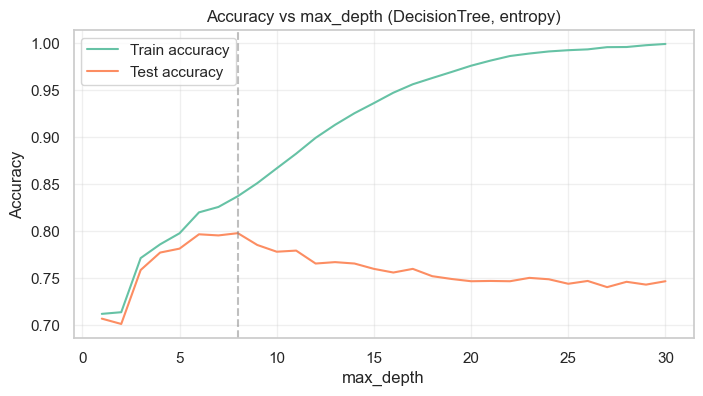

In [79]:
# Перебор глубин
depths = range(1, 31)
scores = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=d)
    clf.fit(X_train, y_train)

    y_pred_train = clf.predict(X_train)
    y_pred_test  = clf.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)

    scores.append((d, acc_train, acc_test))

# В таблицу и выбор лучшей глубины по accuracy теста
scores = np.array(scores, dtype=float)
best_idx = np.argmax(scores[:, 2])        # колонка 2 = accuracy на тесте
best_depth = int(scores[best_idx, 0])
best_acc = scores[best_idx, 2]

print(f"Максимальная accuracy на тесте: {best_acc:.2f}")
print(f"Глубина дерева при максимальной accuracy: {best_depth}")

# (Опционально) Визуализация train/test accuracy от глубины
plt.figure(figsize=(8, 4))
plt.plot(depths, scores[:, 1], label='Train accuracy')
plt.plot(depths, scores[:, 2], label='Test accuracy')
plt.axvline(best_depth, color='grey', linestyle='--', alpha=0.5)
plt.title('Accuracy vs max_depth (DecisionTree, entropy)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [80]:
# Модель случайного леса
rf = ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Обучение
rf.fit(X_train, y_train)

# Прогноз и оценка качества
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy (RandomForest): {acc:.4f}")
print("\nОтчёт о классификации:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

Accuracy (RandomForest): 0.8099

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1790
           1       0.78      0.82      0.80      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.81      0.81      0.81      3335

Матрица ошибок:
[[1440  350]
 [ 284 1261]]


### Задания 2 и 3

In [81]:
# Градиентный бустинг
gbc = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)

# Обучение
gbc.fit(X_train, y_train)

# Оценка на тесте
y_pred = gbc.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy (GradientBoosting): {acc:.4f}")
print("\nОтчёт о классификации:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

Accuracy (GradientBoosting): 0.8162

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1790
           1       0.79      0.82      0.80      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335

Матрица ошибок:
[[1461  329]
 [ 284 1261]]


Градиентный бустинг показывает лучшую работу, чем случайный лес:

- выше accuracy (0.8162 > 0.8099);
- выше F1 по классу 0 и по взвешенному среднему;
- меньше ошибок (лучше матрица ошибок: меньше FP).

➡️ Выбираем GradientBoostingClassifier как более сильную модель на данных.

### Задание 4

In [83]:
# стекинг: дерево решений + логистическая регрессия + градиентный бустинг
# метамодель — логистическая регрессия
from sklearn import ensemble, tree, linear_model, metrics

# базовые алгоритмы с параметрами из предыдущих шагов
base_estimators = [
    ("dt", tree.DecisionTreeClassifier(criterion="entropy",
                                       max_depth=8,
                                       random_state=42)),
    ("lr", linear_model.LogisticRegression(solver="sag",
                                           max_iter=1000,
                                           random_state=42)),
    ("gb", ensemble.GradientBoostingClassifier(learning_rate=0.05,
                                               n_estimators=300,
                                               min_samples_leaf=5,
                                               max_depth=5,
                                               random_state=42)),
]

# метамодель
meta_lr = linear_model.LogisticRegression(solver="sag",
                                          max_iter=1000,
                                          random_state=42)

# модель стекинга
stack = ensemble.StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_lr,
    cv=5,
    n_jobs=-1
)

# обучение
stack.fit(X_train, y_train)

# предсказание и оценка
y_pred = stack.predict(X_test)
acc = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy (Stacking): {acc:.4f}")
print("\nОтчёт о классификации:")
print(metrics.classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(metrics.confusion_matrix(y_test, y_pred))

Accuracy (Stacking): 0.8129

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1790
           1       0.80      0.80      0.80      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.81      0.81      0.81      3335

Матрица ошибок:
[[1470  320]
 [ 304 1241]]


### Задание 5

Топ признаков по важности (Gradient Boosting):
duration             0.519613
pdays                0.125313
age                  0.086087
housing              0.081354
balance              0.064232
day                  0.046781
previous             0.033923
campaign             0.018948
loan                 0.013133
education_encoded    0.009929
default              0.000687
dtype: float64


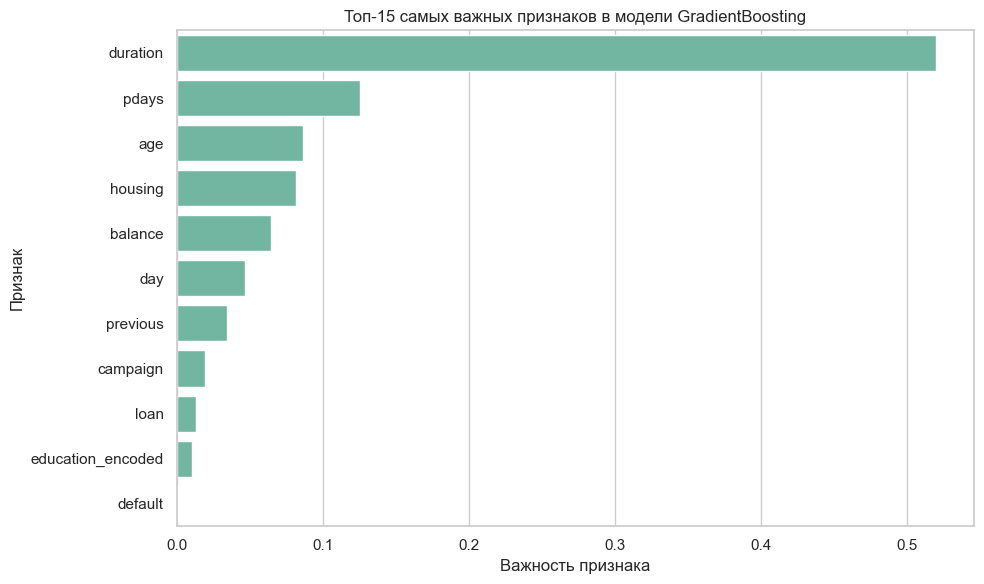

In [84]:
# имена признаков
feat_names = getattr(X_train, "columns", np.arange(X_train.shape[1]).astype(str))

# извлекаем важности
importances = gbc.feature_importances_

# оформляем в Series и сортируем
imp_ser = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# вывод Топ-15
top_n = 15
print("Топ признаков по важности (Gradient Boosting):")
print(imp_ser.head(top_n))

# визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x=imp_ser.head(top_n).values, y=imp_ser.head(top_n).index)
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.title("Топ-15 самых важных признаков в модели GradientBoosting")
plt.tight_layout()
plt.show()

### Задания 6,7,8

In [85]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# === objective для Optuna ===
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200, step=1),
        "max_depth": trial.suggest_int("max_depth", 10, 30, step=1),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 10, step=1),
        "criterion": "gini",
        "random_state": 42,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring="accuracy", n_jobs=-1
    ).mean()

    return score  # maximize


# === запуск исследования ===
sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=60, show_progress_bar=True)  # при желании увеличьте n_trials

print("Лучший скор (CV accuracy):", study.best_value)
print("Лучшие параметры:", study.best_params)

# === обучение финальной модели на лучших параметрах ===
best_rf = RandomForestClassifier(
    **study.best_params, criterion="gini", random_state=42, n_jobs=-1
)
best_rf.fit(X_train, y_train)

# === оценка на тесте ===
y_pred = best_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy на тестовой выборке: {acc:.4f}\n")

print("Отчёт о классификации:")
print(classification_report(y_test, y_pred))

print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))

[I 2025-08-20 16:49:02,624] A new study created in memory with name: no-name-b13556ab-84e6-4d50-8846-1f4cf82fbdca
Best trial: 0. Best value: 0.816248:   2%|▏         | 1/60 [00:03<03:32,  3.60s/it]

[I 2025-08-20 16:49:06,226] Trial 0 finished with value: 0.816248153618907 and parameters: {'n_estimators': 137, 'max_depth': 29, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.816248153618907.


Best trial: 1. Best value: 0.816396:   3%|▎         | 2/60 [00:07<03:29,  3.62s/it]

[I 2025-08-20 16:49:09,850] Trial 1 finished with value: 0.8163958641063516 and parameters: {'n_estimators': 160, 'max_depth': 13, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8163958641063516.


Best trial: 2. Best value: 0.816839:   5%|▌         | 3/60 [00:09<03:03,  3.21s/it]

...

[I 2025-08-20 16:49:57,879] Trial 57 finished with value: 0.8155096011816839 and parameters: {'n_estimators': 142, 'max_depth': 12, 'min_samples_leaf': 4}. Best is trial 52 with value: 0.818168389955687.


Best trial: 52. Best value: 0.818168:  98%|█████████▊| 59/60 [00:56<00:00,  1.31it/s]

[I 2025-08-20 16:49:58,696] Trial 58 finished with value: 0.81698670605613 and parameters: {'n_estimators': 186, 'max_depth': 15, 'min_samples_leaf': 8}. Best is trial 52 with value: 0.818168389955687.


Best trial: 52. Best value: 0.818168: 100%|██████████| 60/60 [00:56<00:00,  1.05it/s]


[I 2025-08-20 16:49:59,563] Trial 59 finished with value: 0.8149187592319056 and parameters: {'n_estimators': 190, 'max_depth': 18, 'min_samples_leaf': 2}. Best is trial 52 with value: 0.818168389955687.
Лучший скор (CV accuracy): 0.818168389955687
Лучшие параметры: {'n_estimators': 195, 'max_depth': 12, 'min_samples_leaf': 3}

Accuracy на тестовой выборке: 0.8144

Отчёт о классификации:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      1790
           1       0.79      0.82      0.80      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.82      0.81      0.81      3335

Матрица ошибок:
[[1446  344]
 [ 275 1270]]


# Сравнение моделей: Optuna (Random Forest) vs Stacking

## 1. Модель, оптимизированная через Optuna (Random Forest)
- **Лучшие параметры:**  
  - `n_estimators = 195`  
  - `max_depth = 12`  
  - `min_samples_leaf = 3`  

- **Accuracy:** `0.8144`  

- **Матрица ошибок:**  
[[1446 344]
[ 275 1270]]


- **Метрики:**
- Класс 0: precision = 0.84, recall = 0.81, f1-score = 0.82  
- Класс 1: precision = 0.79, recall = 0.82, f1-score = 0.80  
- Средние значения: precision = 0.82, recall = 0.81, f1-score = 0.81  

---

## 2. Мета-модель (Stacking, логистическая регрессия)
- **Accuracy:** `0.8129`  

- **Матрица ошибок:**  
[[1470 320]
[ 304 1241]]


- **Метрики:**
- Класс 0: precision = 0.83, recall = 0.82, f1-score = 0.82  
- Класс 1: precision = 0.80, recall = 0.80, f1-score = 0.80  
- Средние значения: precision = 0.81, recall = 0.81, f1-score = 0.81  

---

## 3. Сравнение моделей
1. **Accuracy**:  
 - Optuna (Random Forest) — **0.8144**  
 - Stacking — **0.8129**  
 → Random Forest чуть лучше.  

2. **Recall (Класс 1):**  
 - Optuna (Random Forest) — **0.82**  
 - Stacking — **0.80**  
 → Optuna лучше находит положительные примеры.  

3. **Precision (Класс 1):**  
 - Optuna (Random Forest) — **0.79**  
 - Stacking — **0.80**  
 → Stacking чуть меньше даёт ложноположительных результатов.  

4. **F1-score:**  
 Обе модели примерно равны (**0.81 vs 0.81**).  

---

## 4. Вывод
Обе модели показали схожие результаты, однако:  
- **Optuna-оптимизированный Random Forest** выигрывает по accuracy и recall для положительного класса.  
- **Stacking** немного лучше по precision, но уступает в recall.  

✅ **Итог:** предпочтительнее использовать **Random Forest, оптимизированный через Optuna**, так как он более сбалансирован и эффективнее выявляет объекты положительного класса.  